In [ ]:
import numpy as np
import trimesh
import matplotlib.pyplot as plt

In [ ]:
from photontracer import Simulation, Material, MaterialType, MeshGeometry, IsotropicRayGenerator, OutputType, LengthUnit

In [3]:
# create a mesh representation af a sphere
sph_mesh = trimesh.creation.icosphere(subdivisions=5, radius=1.0)
sph_geometry = MeshGeometry(sph_mesh.vertices, sph_mesh.faces)

In [4]:
# save as obj file
sph_mesh.export("sphere.obj")

'# https://github.com/mikedh/trimesh\nv -0.52573111 0.85065081 0.00000000\nv 0.52573111 0.85065081 0.00000000\nv -0.52573111 -0.85065081 0.00000000\nv 0.52573111 -0.85065081 0.00000000\nv 0.00000000 -0.52573111 0.85065081\nv 0.00000000 0.52573111 0.85065081\nv 0.00000000 -0.52573111 -0.85065081\nv 0.00000000 0.52573111 -0.85065081\nv 0.85065081 0.00000000 -0.52573111\nv 0.85065081 0.00000000 0.52573111\nv -0.85065081 0.00000000 -0.52573111\nv -0.85065081 0.00000000 0.52573111\nv 0.00000000 1.00000000 0.00000000\nv 0.00000000 -1.00000000 0.00000000\nv -0.30901699 -0.80901699 0.50000000\nv 0.30901699 -0.80901699 0.50000000\nv -0.30901699 0.80901699 0.50000000\nv 0.30901699 0.80901699 0.50000000\nv 0.00000000 0.00000000 1.00000000\nv -0.30901699 -0.80901699 -0.50000000\nv 0.30901699 -0.80901699 -0.50000000\nv -0.30901699 0.80901699 -0.50000000\nv 0.30901699 0.80901699 -0.50000000\nv 0.00000000 0.00000000 -1.00000000\nv 0.80901699 0.50000000 -0.30901699\nv 0.80901699 -0.50000000 -0.3090169

In [5]:
wavelength_um = 1.5

materials = [
    Material(MaterialType.REFRACTIVE, 1+0j),  # vacuum
    Material(MaterialType.REFRACTIVE, 1.33+1e-5j) # water
]

In [6]:
sim = Simulation(0)
sim.length_unit = LengthUnit.MILLI_METER

Selecting GPU device ID: 1/1
Using device: NVIDIA GeForce RTX 3090


In [7]:
sim.geometry = sph_geometry
sim.materials = materials
sim.wavelength_um = wavelength_um

In [8]:
number_of_rays = 10_000_000
s_in = (1.0, np.nan, np.nan, 0.0)
ray_generator = IsotropicRayGenerator(
    number_of_rays=number_of_rays,
    center=(0, 0, 0),
    source_radius=1.1,
    offset_radius=1.
)

sim.ray_generator = ray_generator

In [9]:
simulation_outputs = [
    OutputType.RAY_STATE, OutputType.SCATTERING_COUNT,
    OutputType.STOKES_VECTOR, OutputType.STOKES_VECTOR_IN, 
    OutputType.SCATTERING_ANGLE
]

sim.outputs = simulation_outputs

In [10]:
def run_sim(sim, stokes):
    sim.stokes_vector = stokes
    sim.max_scattering_count = 30
    sim.run()
    stokes = sim.get_output_buffer(OutputType.STOKES_VECTOR)
    stokes_in = sim.get_output_buffer(OutputType.STOKES_VECTOR_IN)
    ray_state = sim.get_output_buffer(OutputType.RAY_STATE)
    scattering_count = sim.get_output_buffer(OutputType.SCATTERING_COUNT)
    angle = sim.get_output_buffer(OutputType.SCATTERING_ANGLE)

    no_hit = scattering_count == 0
    absorbed = ray_state == 1
    max_scattering_count = scattering_count >= 20

    print(absorbed.sum()/number_of_rays)
    escape = ~(no_hit | absorbed | max_scattering_count)

    s_o = stokes[escape]
    s_i = stokes_in[escape]
    scattering_count_o = scattering_count[escape]
    an = angle[escape]
    st = ray_state[escape]
    return an, s_o, s_i, scattering_count_o, st

In [11]:
angle, s_o, s_i, depth_o, st = run_sim(sim, (1.0, np.nan, np.nan, 0.0))
angle_c, s_o_c, s_i_c, depth_o_c, st_c = run_sim(sim, (1.0, 0.0, 0.0, np.nan))

Starting simulation
Finished raytracing in 745 ms
0.1329969
Starting simulation
Finished raytracing in 742 ms
0.1330027


In [12]:
depth_o.mean(), depth_o.max()

(np.float64(1.981339697568798), np.uint32(19))

In [13]:
nbins = 180
bin_edges = np.linspace(0.0, np.pi, nbins+1)   # radians

In [14]:
hist_counts, _ = np.histogram(angle, bins=bin_edges)
# bin centers and widths
centers = 0.5*(bin_edges[:-1] + bin_edges[1:])
dtheta = bin_edges[1] - bin_edges[0]

# solid angle of ring (unit sphere)
dOmega = 2.0 * np.pi * np.sin(centers) * dtheta

# intensity per steradian (compare to p11-like phase functions)
intensity_per_sr = hist_counts / dOmega

p11 = 4 * np.pi * intensity_per_sr / len(angle)

In [15]:
def average_per_angle(value_array, bin_idx):
    average_value = np.zeros(np.max(bin_idx)+1)
    sums = np.bincount(bin_idx, weights=value_array, minlength=nbins)
    counts = np.bincount(bin_idx, minlength=nbins)
    # Avoid division by zero
    average_value = np.divide(sums, counts, out=np.zeros_like(sums), where=counts > 0)
    return average_value

In [16]:
centers_degrees = centers / np.pi * 180.0  # degrees

In [17]:
nbins = len(bin_edges) - 1
bin_idx = np.digitize(angle, bins=bin_edges) - 1
bin_idx[bin_idx < 0] = 0
bin_idx[bin_idx >= nbins] = nbins-1

In [18]:
nbins = len(bin_edges) - 1
bin_idx_c = np.digitize(angle_c, bins=bin_edges) - 1
bin_idx_c[bin_idx_c < 0] = 0
bin_idx_c[bin_idx_c >= nbins] = nbins-1

In [19]:
m11 = average_per_angle(s_o[:,0], bin_idx)
m21 = average_per_angle(s_o[:,1], bin_idx)
m22 = average_per_angle(2 * s_o[:,1] * s_i[:,1], bin_idx)
m23 = average_per_angle(2 * s_o[:,1] * s_i[:,2], bin_idx)
m32 = average_per_angle(2 * s_o[:,2] * s_i[:,1], bin_idx)
m33 = average_per_angle(2 * s_o[:,2] * s_i[:,2], bin_idx)
m43 = average_per_angle(2 * s_o[:,3] * s_i[:,2], bin_idx)
m44 = average_per_angle(2 * s_o_c[:,3] * s_i_c[:,3], bin_idx_c)

In [20]:
siris_output_S = np.loadtxt("data/SPH_SIRIS-S.out")

In [21]:
angles_siris = siris_output_S.T[0]
p = siris_output_S.T[1:].reshape((4, 4, 182))
p.shape

(4, 4, 182)

In [22]:
p.shape, angles_siris.shape

((4, 4, 182), (182,))

In [23]:
p[0,0,:].sum()

np.float64(411.76384958)

In [24]:
mie_data = np.loadtxt("data/SPH_MiePlot.txt", skiprows=21)
mie_angles = mie_data.T[0]

s11_mie = mie_data.T[1]
s12_mie = mie_data.T[2]
s33_mie = mie_data.T[3]
s34_mie = mie_data.T[4]

# rolling average for smoother curves
def rolling_average(data, window_size=10):
    return np.convolve(data, np.ones(window_size)/window_size, mode='same')

mie_angles_smooth = rolling_average(mie_angles, window_size=30)
s11_mie_smooth = rolling_average(s11_mie, window_size=30)
s12_mie_smooth = rolling_average(s12_mie, window_size=30)
s33_mie_smooth = rolling_average(s33_mie, window_size=30)
s34_mie_smooth = rolling_average(s34_mie, window_size=30)

normalization_factor = 0.5 * np.sum(s11_mie * np.sin(mie_angles * np.pi / 180) * (mie_angles[1] - mie_angles[0]) * np.pi / 180)
s11_mie_smooth_norm = s11_mie_smooth / normalization_factor

In [25]:
norm_test = 0.5 * np.sum(p[0,0,:] * np.sin(angles_siris * np.pi / 180) * (angles_siris[1] - angles_siris[0]) * np.pi / 180)
norm_test

np.float64(1.0055241602768414)

In [26]:
mie_angles.shape

(1801,)

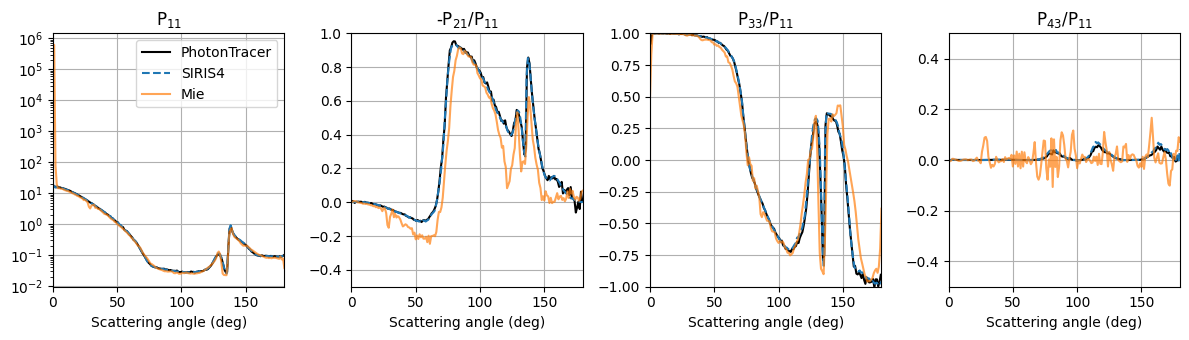

In [27]:
import matplotlib as mpl
# use tableau colorblind-friendly
colors = mpl.cm.tab10.colors

fig, ax = plt.subplots(1, 4, figsize=(12, 3.5))

ax[0].plot(centers_degrees, p11, label="PhotonTracer", color='black')
ax[1].plot(centers_degrees, -m21, label="PhotonTracer P21/P11", color='black')
ax[2].plot(centers_degrees, m33, label="PhotonTracer P33/P11", color='black')
ax[3].plot(centers_degrees, m43, label="PhotonTracer P43/P11", color='black')


ax[0].plot(angles_siris, p[0,0,:], label="SIRIS4", ls='--')
ax[1].plot(angles_siris, -p[1,0]/p[0,0], label="SIRIS4 P21/P11", ls='--')
ax[2].plot(angles_siris, p[2,2]/p[0,0], label="SIRIS4 P33/P11", ls='--')
ax[3].plot(angles_siris, p[3,2]/p[0,0], label="SIRIS4 P43/P11", ls='--')

ax[0].plot(mie_angles[::10], s11_mie_smooth_norm[::10], label="Mie", color=colors[1], alpha=0.7)
ax[1].plot(mie_angles[::10], -s12_mie_smooth[::10], label="Mie P21/P11", color=colors[1], alpha=0.7)
ax[2].plot(mie_angles[::10], s33_mie_smooth[::10], label="Mie P33/P11", color=colors[1], alpha=0.7)
ax[3].plot(mie_angles[::10], -s34_mie_smooth[::10], label="Mie P43/P11", color=colors[1], alpha=0.7)

ax[0].set_title("P$_{11}$")
ax[0].set_yscale("log")
ax[1].set_title("-P$_{21}$/P$_{11}$")
ax[2].set_title("P$_{33}$/P$_{11}$")
ax[3].set_title("P$_{43}$/P$_{11}$")

ax[0].legend()



ax[1].set_ylim([-.5, 1.])
ax[2].set_ylim([-1., 1.])
ax[3].set_ylim([-0.5, 0.5])
#plt.ylabel("-p21/p11")
for i in range(4):
    ax[i].set_xlabel("Scattering angle (deg)")

    ax[i].grid()
    ax[i].set_xlim([0, 180])

fig.tight_layout()